# Surface Mining Screening

* **Products used:** 
[gm_s2_annual](https://explorer.digitalearth.africa/products/gm_s2_annual/extents), 
[s1_rtc](https://explorer.digitalearth.africa/products/s1_rtc/extents), 
[wofs_ls_summary_annual](https://explorer.digitalearth.africa/products/wofs_ls_summary_annual/extents)

## Background

[Surface mining](https://americanmineservices.com/types-of-surface-mining) refers to the removal of the terrain surface to access minerals underneath. In particular, surface mining is used to retrieve sand, gravel, stones, coal, iron and other metals. Surface mining is often more cost-effective than gouging tunnels and subterranean shafts to access minerals underground.

Although surface mining contributes to the source of income for a country, these operations can result in deleterious impacts on farmlands, forests, and water bodies. Government officials are making efforts to identify areas of these mining activities. 

This notebook demonstrates a method for identifying areas of surface mining activity. The notebook combines methods based on vegetation loss and water detection. Although the notebook aids in detecting these areas, further verification by government agencies or institutions are required to validate the operations on the ground.

## Description

Surface mining operations often result in the clearing of vegetation and the development of water from the land. Using remote sensing images from [Sentinel-2 GEOMAD](https://docs.digitalearthafrica.org/en/latest/data_specs/GeoMAD_specs.html) or [Sentinel-1](https://docs.digitalearthafrica.org/en/latest/data_specs/Sentinel-1_specs.html), and DE Africa's [Water Observations from Space (WOfS)](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html) product, this notebook screen areas where there is a possibility of surface mining. 

The notebook uses Normalised Difference Vegetation Index (for sentinel-2) or the Radar Vegetation Index (for sentinel-1) to determine vegetation loss, where loss occurs if the change in vegetation index is negative. DE Africa's WOfS product is used to identify water.

The final product identifies pixels that exhibit vegetation loss, and the presence of water.
In most cases, these algorithms can be used to identify clusters of pixels that have experienced change and allow targeted investigation of those areas by local or regional governments.

The notebook demonstrates how to:

1. Load data for a given location and time period
2. Calculate the vegetation change
3. Calculate the presence of water
4. Combine vegetation change and water extent change into one plot to show possible mining areas

***

## Getting started

### Load packages

In [1]:
# Import functions for this notebook
from Surface_mining_screening import run_surface_mining_screening

### Analysis parameters

The following cell sets the parameters, which define the area of interest and the length of time to conduct the analysis over.
The area of interest must be defined with a shapefile (`.shp`), a geojosn (`.geojson`), or a KML file (`.kml`).

The parameters are:

* `start_year`: The year to start the analysis
* `end_year`: The year to end the analysis
* `product` : whether oto use Sentinel-2 or sentinel-1 for the analysis, acceptable values are `'s2'` or `'s1'`
* `threhold`: The threshold to use for indentifying vegetaton loss, this can either be a float e.g. `-0.15`, or `'otsu'`, in which case the threshold will be automatically identified using the otsu method.
* `vector_file`: The file path and name of a vector file containing the extent. Can be a `.kml` file, or a `.shp` file.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The example covers part of the Essen Apam Forest Reserve, Ghana, and uses the shapefile provided in **Supplementary Data**.

In [2]:
start_year = 2017
end_year = 2025
product= 's2'
threshold = -0.1
vector_file = "./data/Apam_forest.shp"



> Note, if the product used is Sentinel-1, this cell can take a few minutes to run as annual medians are calculated on-the-fly

*1) Loading AOI vector*

Label(value='')

Map(center=[np.float64(6.328635468846285), np.float64(-1.8708615021743045)], controls=(ZoomControl(options=['p…

*2) Loading imagery and WOfS*

*3) Calculating vegetation loss*

...

*6) Exporting CSV tables*

*7) Exporting GeoTIFF outputs*

*Exporting yearly vegetation loss masks as GeoTIFFs*

*8) Quick-look RGB composites*

*Saving RGB composites per year (PNG, dpi=300)*

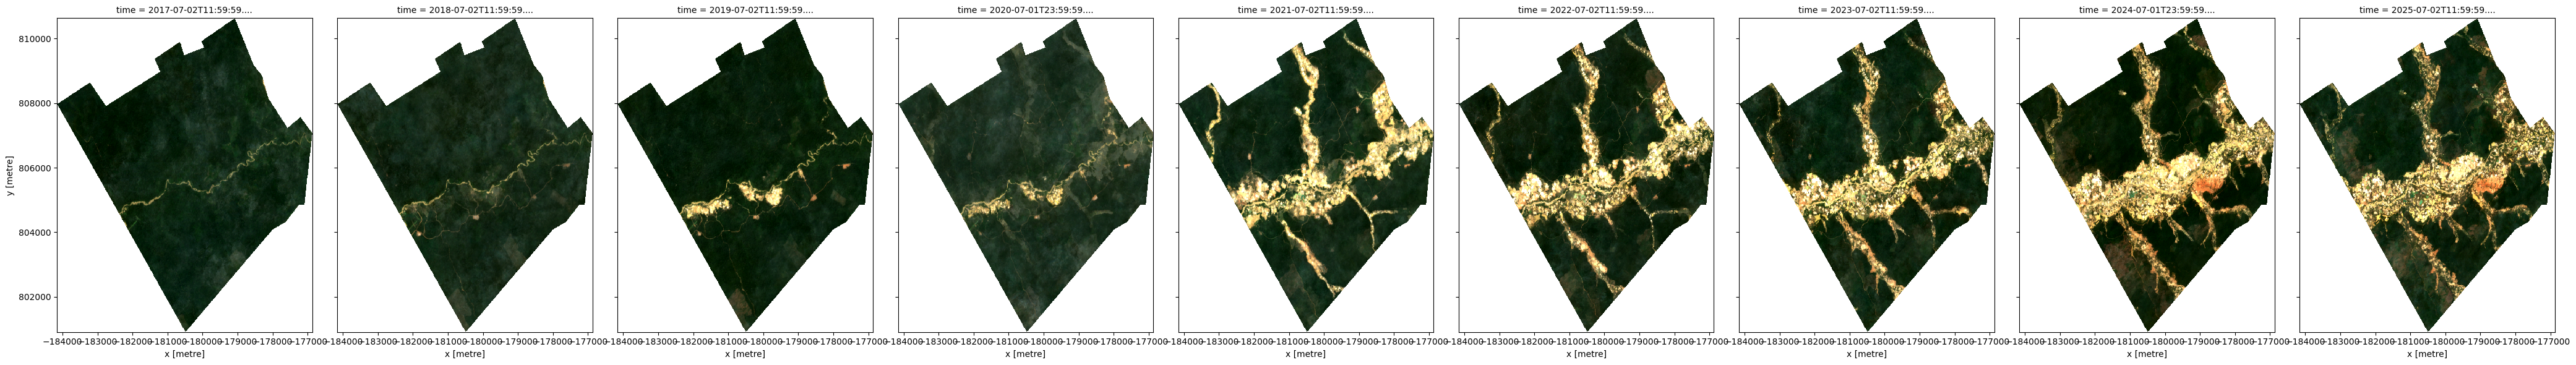

In [ ]:
run_surface_mining_screening(vector_file, start_year, end_year, product= product, threshold=threshold)

---

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:**

In [ ]:
import datacube
print(datacube.__version__)

**Last Tested:**

In [ ]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')